## <p style="text-align: right;"> &#9989; Put your name here</p>

# CMSE 201: Quiz 4 (Section 002 Spring 2023)

The goal of this quiz is to give you the opportunity to test out more of the skills that you've developed thus far this semester. In particular, you'll reflect on what you know about writing code using Python and showcase some of your more recently acquired programming skills.

**Important note about using online resources**: This exam is "open internet". That means that you can look up documentation, google how to accomplish certain Python tasks, etc. Being able to effectively use the internet for computational modeling and data science is a very important skill, so we want to make sure you have the opportunity to exercise that skill. **However, the use of any person-to-person communication software is absolutely not acceptable.**

**Do your own work.** This quiz is designed to give *you* the opportunity to show the instructor what you can do and you should hold yourself accountable for maintaining a high level of academic integrity. Any violation of academic integrity could result in you receiving a zero on the quiz.

There are a total of <font color="red">**36**</font> possible on this quiz.

**If you get stuck any particular question, do you your best to provide what your solution *might* look like for later parts of the exam in order to create opportunities for partial credit. Questions 4 and 5 can be answered even if you don't get your code working by interpretting the provided plots.**

### ANSWER (for making sure this gets removed) ###

## Template Guidelines

**Learning Objectives from Homework 4:**
* Using `solve_ivp` to solve a set of ODEs for the purposes of modeling a phenomenon
* Using `matplotlib` to visualize models
* Building compartmental models
* Interpreting model results

**Learning Objectives the Quiz will assess:**
* Solving ODEs numerically using `solve_ivp`
* Visualizing model results using `matplotlib`
* Interpretting model results from a solved set of ODEs using provided initial conditions and model parameters.

**Learning objectives that we don't have time/space for**:

* Building a compartmental model from scratch

**Quiz Duration:** 30 minutes (ideally, time can be extended slightly if needed)
* This means your TAs/LAs should be able to complete the quiz in at most 10 minutes (if TA/LA completion time is closer to 15, consider extending quiz to 40 minutes)

**Notes:**
* The structure and rubric provided here is a suggestion and an example of the difficulty level expected. However, as long as your quiz assesses the learning objectives listed under "Learning Objectives the Quiz will assess" section above, you can differ from this structure. If you aren't sure that your quiz does that, run it by another instructor (lead isntructor, other faculty, TA, or LA)
* The examples provided are examples and **should not be used directly without changes in any quizzes**
* These quizzes are important for students to assess how well they understand the material independent of their groups, so when grading, be sure to provide feedback on where points were deducted. **You should also have a clear rubric with clearly stated point values, but you do not need to follow the point values included in this template**.
* Quizzes should be written with ample time for TAs/LAs to review! **Your TA and LAs should have at least 48 hours to review the quiz before it is given**.
* Quizzes (and instructor solution with point-by-point rubrics) should be **pushed to the GitHub repo for record-keeping**. Put your section's version in a sub-folder with the name `Section-###` where "###" is your section number.

**Overall Structure:**

1. A section that focuses on assessing if students correctly can use solve_ivp to solve an initial value program given a set of ODEs, a set of initial conditions, and a set of model parameters. Once they have a functioning solution, they should be asked to interpret their results.

---
# Academic integrity statement (1 point)

In the markdown cell below, put your personal academic integrity statement. By including this statement, you are confirming that you are submitting this as your own work and not that of someone else.


<font size=+3>&#9998;</font> *Put your personal academic integrity statement here.*

---
## Part 1: Modeling a system using `solve_ivp` (35 points)

&#9989;&nbsp; **Question 1 (15 points)**: In this question, you're going to think about how one could build a model to study how the biomass (https://en.wikipedia.org/wiki/Biomass_(ecology)) in a forest changes as a function of time. In particular, we'll be thinking about how biomass moves between living trees, dead trees, and humus, which is defined to be "the organic component of soil, formed by the decomposition of leaves and other plant material by soil microorganisms." We can model this system with the following equations:

$$ \frac{dx}{dt} = -x + 3y $$
$$ \frac{dy}{dt} = -3y + 5z $$
$$ \frac{dz}{dt} = -5z $$

where $x$ is the biomass that has decayed in humus, $y$ is the biomass in dead trees, and $z$ is the biomass in living trees. Given that we're talking about the life and death of trees, we assume will use **decades** (10s of years) as our unit of time, $t$. This means that, for example, $t = 2$ would be _20 years_. 

Solve this biomass system using `solve_ivp`. Assuming the following initial conditions:

* $x(0) = 0$
* $y(0) = 0$
* $z(0) = 809601$ in units of thousands of tons (based on 2012 data for forests in Michigan).

Evolve the model for 5 decades (50 years) using a timestep of $\Delta t = 0.01$ decades.

**Code you need to write to solve this problem**:
* A function that takes in a set of time values as well as the current values for $x$, $y$, and $z$ and **returns** the derivatives for each variable, $\frac{dx}{dt}$, $\frac{dy}{dt}$, and $\frac{dz}{dt}$. This would be your "derivatives" function that `solve_ivp` needs.
* A set of variables for storing your initial conditions, $x_0$, $y_0$, and $z_0$, set to the correct initial values.
* A variable that stores all the times for which you want to solve the system of ODEs, you can generate these times using `np.arange()`. The times should match the time range and timestep size specified above.
* Code that calls `solve_ivp` using all of the appropriate arguments and stores the result. 
* Code that unpacks the solution so that you can plot it.

**Note**: you will not need the "`args`" argument for `solve_ivp` for this case because any model parameters that might be needed for this system are provided directly as numbers in the set of  ODEs include above.

In [1]:
# The import commands you need are provided here
from scipy.integrate import solve_ivp
import numpy as np
import matplotlib.pyplot as plt

# Put your code here


In [2]:
### ANSWER ###

# Import needed modules
from scipy.integrate import solve_ivp
import numpy as np

# Define the derivatives function
def derivs(t, vals):
    x, y, z = vals
    dxdt = -x + 3*y
    dydt = -3*y + 5*z
    dzdt = -5*z
    return dxdt, dydt, dzdt

# Solve the system
x0 = 0
y0 = 0
z0 = 809601
ICs = [x0, y0, z0]
t = np.arange(0, 5, 0.01)
sol = solve_ivp(derivs, (t[0], t[-1]),ICs, t_eval=t)
x = sol.y[0,:]
y = sol.y[1,:]
z = sol.y[2,:]
print(x)

# 6 points for the function
    # 1 point for the function definition and arguments
    # 1 point for unpacking the input values
    # 1 point for the correct derivative equations for x, y, and z (3 points total)
    # 1 point for the return statement with all three derivatives

# 2 points for the initial conditions
# 2 points for the time array providing 5 decades (should go from 0 to 5)
# 2 points for the solve_ivp command (with the correct arguments)
# 3 points for unpacking the solution into x, y, and z

[     0.            589.26375408   2287.6599684    4995.89177319
   8620.21788178  13074.5983113   18278.36273601  24155.38785808
  30634.0974076   37647.46214258  45132.01662175  53028.09236024
  61284.97507582  69854.81276376  78692.14493132  87753.90259772
  96999.40829419 106390.37606389 115890.91146197 125467.51155557
 135088.99125054 144724.76381657 154351.97276322 163951.31517094
 173504.34098313 182993.45300613 192401.90690921 201713.81122458
 210914.1273474  219988.66953575 228924.10491067 237707.95345612
 246328.588019   254775.23430916 263037.9963088  271110.09735451
 278988.80711448 286671.83201928 294157.0076285  301442.29863082
 308525.79884394 315405.73121463 322080.44781872 328548.42986107
 334808.28767561 340858.76072531 346698.7176022  352327.15602736
 357743.20285092 362946.11405208 367935.30111761 372713.02710533
 377283.65791391 381650.87651691 385818.27582732 389789.3586976
 393567.53791965 397156.13622485 400558.38628402 403777.43070744
 406816.32204485 409678.02

&#9989;&nbsp; **Question 2 (8 points)**: Now that you have a solution to the model, make a single plot that displays the evolution of all three variables, humus, dead trees, and living trees as a function time (you can choose to plot it in decades or years). Each line should be a different color and your plot should contain a $x$-axis label, a $y$-axis label, and a legend.

If all goes well, you should end up with something that looks like this:

<img src="https://i.ibb.co/LxDSH48/Quiz4-Q2.png" alt="Quiz4-Q2" border="0" width=500>

In [3]:
# Put your code here


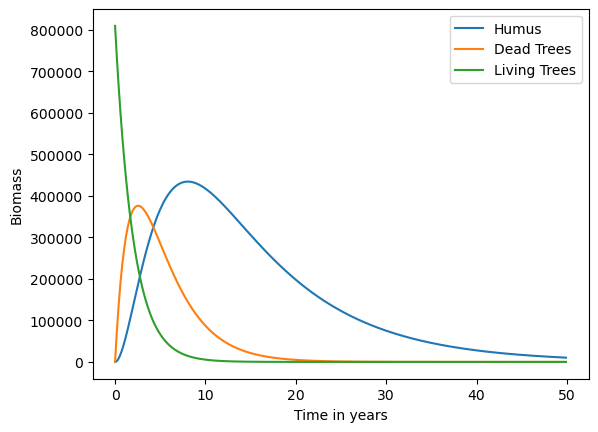

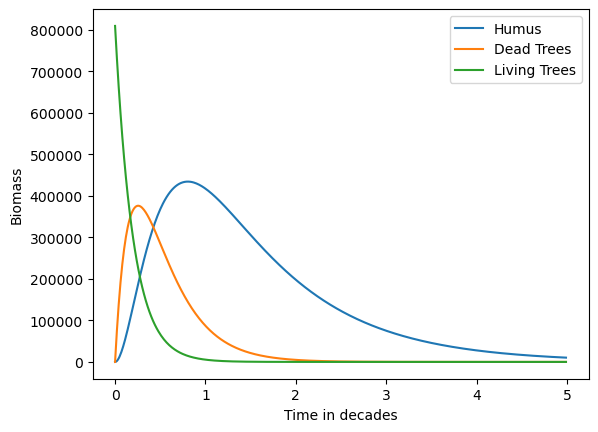

In [4]:
### ANSWER ###
# Import needed modules
import matplotlib.pyplot as plt

# In years
plt.figure(1)
plt.plot(t*10,x,label="Humus")
plt.plot(t*10,y,label="Dead Trees")
plt.plot(t*10,z,label="Living Trees")
plt.xlabel("Time in years")
plt.ylabel("Biomass")
plt.legend()

# In decades
plt.figure(2)
plt.plot(t,x,label="Humus")
plt.plot(t,y,label="Dead Trees")
plt.plot(t,z,label="Living Trees")
plt.xlabel("Time in decades")
plt.ylabel("Biomass")
plt.legend()
plt.savefig("Quiz4_Q2.png")

# 1 points for each line (3 points total)
# 1 point for making each line a different color
# 1 point x-axis label
# 1 point y-axis label
# 2 point legend with correct labels

&#9989;&nbsp; **Question 3 (6 points)**: Make a second plot where you zoom in on just the first two decades of the evolution of the system (again, you can choose to plot it in decades or years). Ensure that all of the same labels are included. **Note**: This should not involve re-running your model, but instead should involve plotting a subset of all of the values using NumPy array indexing. Partial credit will be given you cannot figure out how to use array indexing and choose to re-run the model for less time.

If all goes as planned, you should end up with something that looks like this:

<img src="https://i.ibb.co/KWJZCfr/Quiz4-Q3.png" alt="Quiz4-Q3" border="0" width=500>

In [5]:
# Put your code here


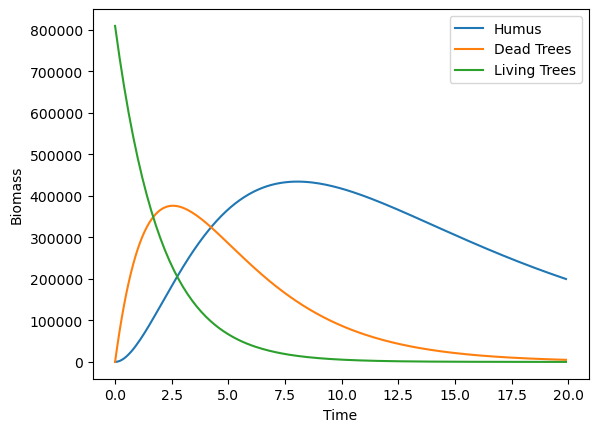

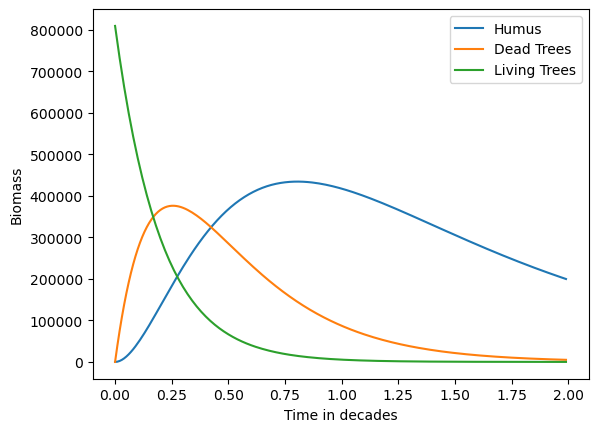

In [6]:
### ANSWER ###
# Import needed modules
import matplotlib.pyplot as plt

stop_index = int(len(t) * 0.4)

# In years
plt.figure(1)
plt.plot(t[0:stop_index]*10,x[0:stop_index],label="Humus")
plt.plot(t[0:stop_index]*10,y[0:stop_index],label="Dead Trees")
plt.plot(t[0:stop_index]*10,z[0:stop_index],label="Living Trees")
plt.xlabel("Time")
plt.ylabel("Biomass")
plt.legend()

# In decades
plt.figure(2)
plt.plot(t[0:stop_index],x[0:stop_index],label="Humus")
plt.plot(t[0:stop_index],y[0:stop_index],label="Dead Trees")
plt.plot(t[0:stop_index],z[0:stop_index],label="Living Trees")
plt.xlabel("Time in decades")
plt.ylabel("Biomass")
plt.legend()
plt.savefig("Quiz4_Q3.png")

# 1 point for plotting each line (3 points total) using correct indexing; half credit for not using correct indexing
# 1 point for correct x and y labels (2 points total)
# 1 point for correct legend

&#9989;&nbsp; **Question 4 (3 points)**: At what point in time is the total amount of living trees half of the starting value? Explain how you determined this. **Note**: It is not necessary to write code to solve this and your answer can be approximate (but you should be able to estimate it to within a half a year precision). If you have time, you are encouraged to write code to find a precise solution, but it is not necessary to receive credit.

*Put your answer here*

In [7]:
# Put any code you care to here


### ANSWER
~1.25 years

*Scoring*:
* 2 points for the correct answer
* 1 point for a reasonable explanation for how they figured it out.

&#9989;&nbsp; **Question 5 (3 points)**: At what point in time does the total amount of biomass in the humus exceed that of the dead trees? Explain how you determined this. **Note**: It is not necessary to write code to solve this and your answer can be approximate (but you should be able to estimate it to within a half a year precision). If you have time, you are encouraged to write code to find a precise solution, but it is not necessary to receive credit.

*Put your answer here*

In [ ]:
# Put any code you care to here


### ANSWER
~4 years

*Scoring*:
* 2 points for the correct answer
* 1 point for a reasonable explanation for how they figured it out.*

---

### Congratulations, you're done!

Submit this quiz by uploading it to the course Desire2Learn web page.  Go to the "Quizzes" section, find the submission folder link for Quiz #4, and upload it there.